# HCAVmix - wine dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## wine dataset

In [2]:
# poison dataset
from clustvartools.datasets import wine
data = wine.data
data.info()

<class 'pandas.DataFrame'>
Index: 21 entries, 2EL to T2
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Label                          21 non-null     str    
 1   Soil                           21 non-null     str    
 2   Odor.Intensity.before.shaking  21 non-null     float64
 3   Aroma.quality.before.shaking   21 non-null     float64
 4   Fruity.before.shaking          21 non-null     float64
 5   Flower.before.shaking          21 non-null     float64
 6   Spice.before.shaking           21 non-null     float64
 7   Visual.intensity               21 non-null     float64
 8   Nuance                         21 non-null     float64
 9   Surface.feeling                21 non-null     float64
 10  Odor.Intensity                 21 non-null     float64
 11  Quality.of.odour               21 non-null     float64
 12  Fruity                         21 non-null     float64
 13  Flower

## Instanciation and training

In [3]:
# instanciation
from clustvartools import HCAVmix
clf = HCAVmix(ncl=4)

### `fit` function

In [4]:
# fit function
clf.fit(data)

,ncl,4
,metric,<function HCA...001C9CCCD39C0>
,linkage,'average'
,sup_var,None
Name,Type,Value
call_,call,call(Xtot= ... sup_var=None)
var_,var,var(cluster=L... 0.95 )


### `fit_transform` function

In [5]:
# fit_transform function - cluster distance
dist = clf.fit_transform(data)
dist

,1,2,3,4
Label,0.985855,0.956859,0.780835,0.886454
Soil,0.805209,0.799291,0.699405,0.796893
Odor.Intensity.before.shaking,0.983665,0.900058,0.741284,0.989587
Aroma.quality.before.shaking,0.987000,0.703708,0.980396,0.996860
Fruity.before.shaking,0.989686,0.782458,0.991290,0.995132
Flower.before.shaking,0.332704,0.922811,0.984402,0.954381
Spice.before.shaking,0.976590,0.963876,0.811835,0.948356
Visual.intensity,0.999999,0.682789,0.938751,0.975930
Nuance,0.999520,0.733687,0.943186,0.978814
Surface.feeling,0.998539,0.683907,0.947789,0.976475


### `transform` function

In [6]:
# transform function - cluster distance
dist = clf.transform(data)
dist

,1,2,3,4
Label,0.985855,0.956859,0.780835,8.864542e-01
Soil,0.805209,0.799291,0.690352,7.968935e-01
Odor.Intensity.before.shaking,0.983665,0.900058,0.677998,9.895869e-01
Aroma.quality.before.shaking,0.987000,0.703708,0.919539,9.968604e-01
Fruity.before.shaking,0.989686,0.764111,0.957849,9.951322e-01
Flower.before.shaking,0.332704,0.920612,0.956817,9.543805e-01
Spice.before.shaking,0.955933,0.963267,0.750250,9.483556e-01
Visual.intensity,0.977425,0.666181,0.879524,9.759295e-01
Nuance,0.977670,0.677373,0.890807,9.788136e-01
Surface.feeling,0.971579,0.602400,0.907357,9.764749e-01


### `fit_predict` function

In [7]:
# fit_predict function
prediction = clf.fit_predict(data)
prediction.to_frame()

,cluster
Label,3
Soil,3
Odor.Intensity.before.shaking,3
Aroma.quality.before.shaking,2
Fruity.before.shaking,2
Flower.before.shaking,1
Spice.before.shaking,3
Visual.intensity,2
Nuance,2
Surface.feeling,2


### `predict` function

In [8]:
# predict function
prediction = clf.predict(data)
prediction.to_frame()

,cluster
Label,3
Soil,3
Odor.Intensity.before.shaking,3
Aroma.quality.before.shaking,2
Fruity.before.shaking,2
Flower.before.shaking,1
Spice.before.shaking,3
Visual.intensity,2
Nuance,2
Surface.feeling,2


In [9]:
# attributes
from clustvartools import sprintf
sprintf(clf)


**Clustering of Variables - HCAVmix**

*The results are available in the following objects:

name    description
------  -------------------------
.call_  summary called parameters
.var_   results for variables



## Variables informations

In [10]:
# variables informations
var_ = clf.var_
var_._fields

('cluster', 'dist', 'member')

### Cluster distance

In [11]:
# cluster distance
var_.dist

,1,2,3,4
Label,0.985855,0.956859,0.780835,0.886454
Soil,0.805209,0.799291,0.699405,0.796893
Odor.Intensity.before.shaking,0.983665,0.900058,0.741284,0.989587
Aroma.quality.before.shaking,0.987000,0.703708,0.980396,0.996860
Fruity.before.shaking,0.989686,0.782458,0.991290,0.995132
Flower.before.shaking,0.332704,0.922811,0.984402,0.954381
Spice.before.shaking,0.976590,0.963876,0.811835,0.948356
Visual.intensity,0.999999,0.682789,0.938751,0.975930
Nuance,0.999520,0.733687,0.943186,0.978814
Surface.feeling,0.998539,0.683907,0.947789,0.976475


### Cluster member

In [12]:
# cluster member
var_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,Ratio (Own/Next)
13,Flower,1,0.5,0.951541,0.525463
5,Flower.before.shaking,1,0.332704,0.922811,0.360533
23,Alcohol,2,0.89329,0.981473,0.910153
17,Aroma.intensity,2,0.78585,0.968787,0.811169
18,Aroma.persistency,2,0.771227,0.987941,0.78064
19,Aroma.quality,2,0.797889,0.972209,0.820697
3,Aroma.quality.before.shaking,2,0.703708,0.980396,0.717779
22,Astringency,2,0.885253,0.979287,0.903978
20,Attack.intensity,2,0.789678,0.989839,0.797785
24,Balance,2,0.808641,0.999995,0.808645


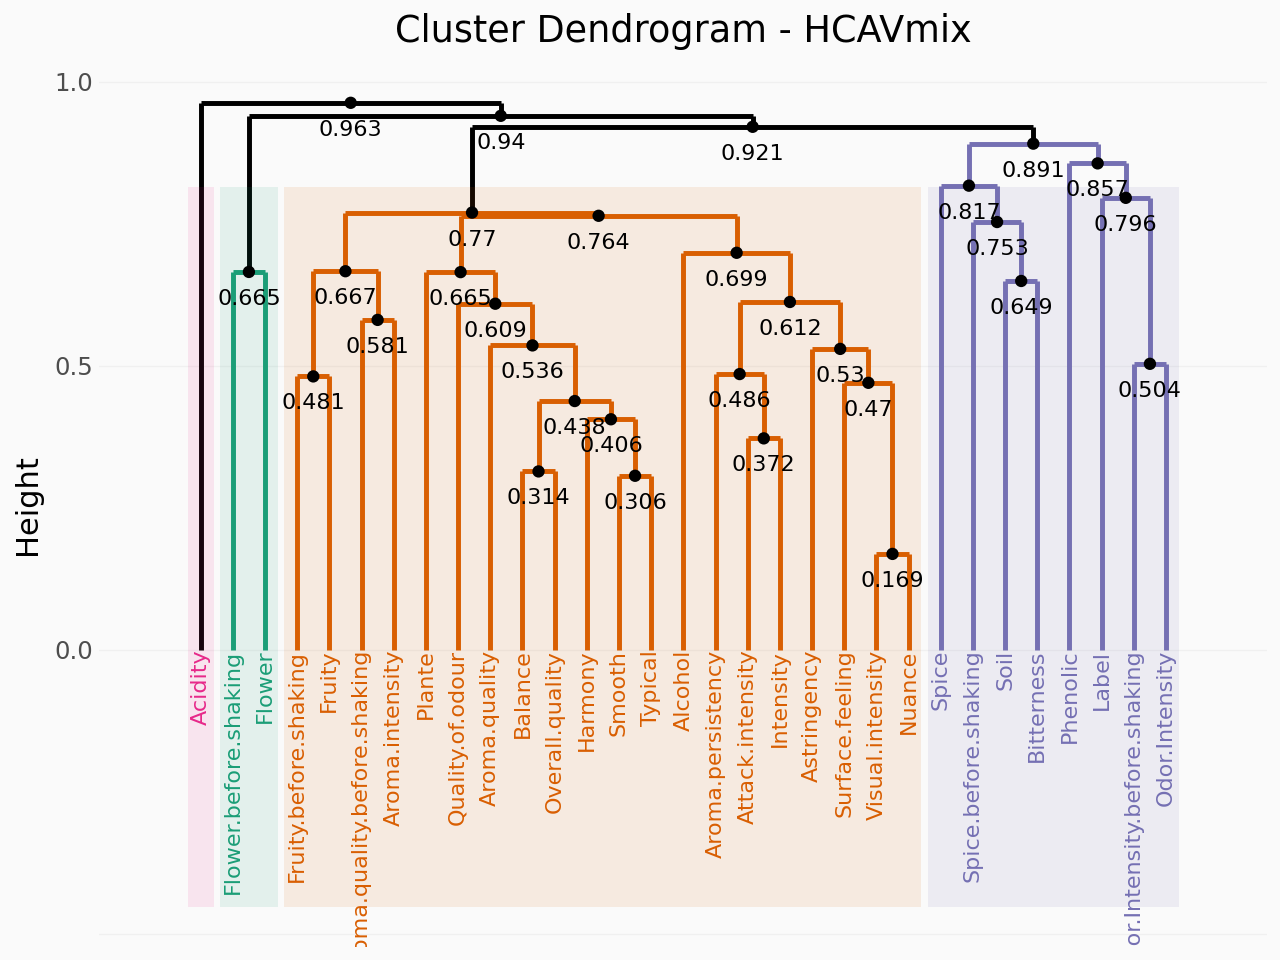

None


In [13]:
# dendrogram
from clustvartools import fviz_dend, fviz_height
p = fviz_dend(obj=clf,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_y=-0.03)
print(p.show())

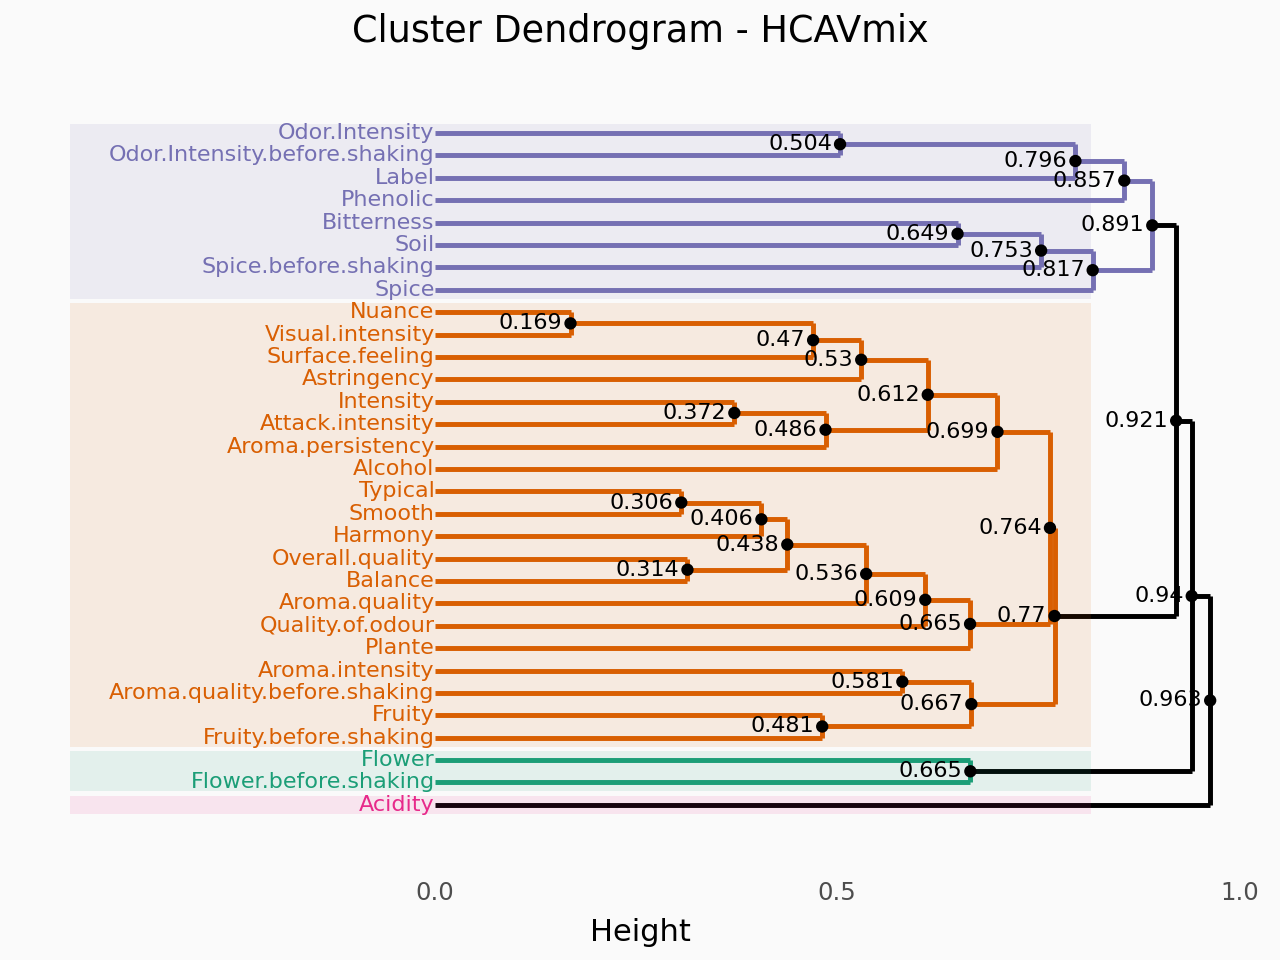

None


In [14]:
# horizon 
p = fviz_dend(obj=clf,
              horiz=True,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_x=-0.01)
print(p.show())

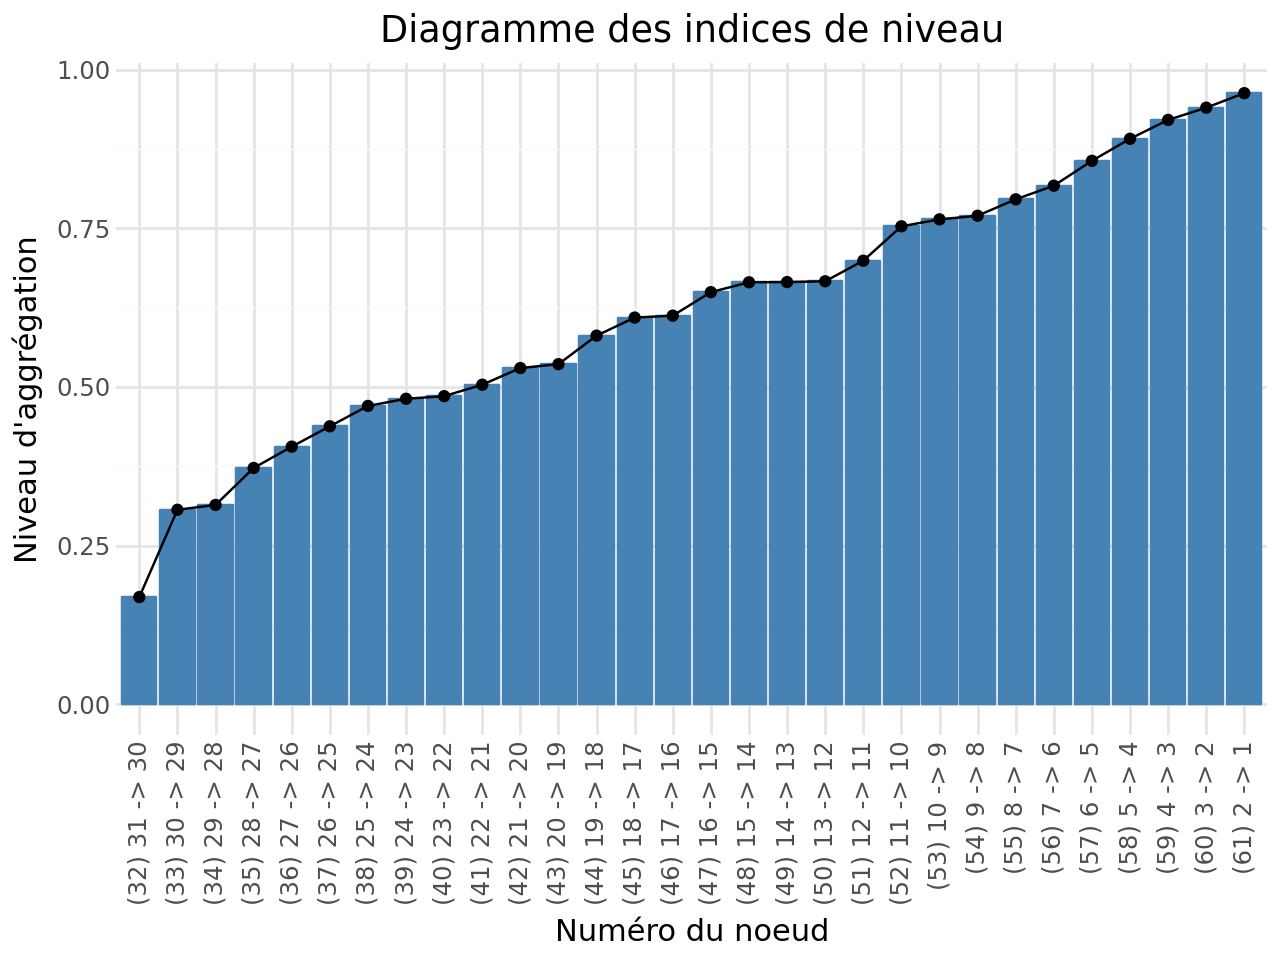

None


In [15]:
# graph of height
p = fviz_height(clf)
print(p.show())

## Summary

In [16]:
# summary
from clustvartools import summary
summary(clf)

                     Clustering of Variables - HCAVmix Results                     

Cluster Distance:
                                    1       2       3       4
Label                          0.9859  0.9569  0.7808  0.8865
Soil                           0.8052  0.7993  0.6994  0.7969
Odor.Intensity.before.shaking  0.9837  0.9001  0.7413  0.9896
Aroma.quality.before.shaking   0.9870  0.7037  0.9804  0.9969
Fruity.before.shaking          0.9897  0.7825  0.9913  0.9951
Flower.before.shaking          0.3327  0.9228  0.9844  0.9544
Spice.before.shaking           0.9766  0.9639  0.8118  0.9484
Visual.intensity               1.0000  0.6828  0.9388  0.9759
Nuance                         0.9995  0.7337  0.9432  0.9788
Surface.feeling                0.9985  0.6839  0.9478  0.9765

Cluster Members and Distance values:
                        Variable Cluster Own Cluster Next Closest  \
0                          Label       3    0.780835     0.886454   
1                           Soil       

In [17]:
# markdown formatting
summary(clf,to_markdown=True)

                     Clustering of Variables - HCAVmix Results                     

Cluster Distance:
                                    1       2       3       4
-----------------------------  ------  ------  ------  ------
Label                          0.9859  0.9569  0.7808  0.8865
Soil                           0.8052  0.7993  0.6994  0.7969
Odor.Intensity.before.shaking  0.9837  0.9001  0.7413  0.9896
Aroma.quality.before.shaking   0.987   0.7037  0.9804  0.9969
Fruity.before.shaking          0.9897  0.7825  0.9913  0.9951
Flower.before.shaking          0.3327  0.9228  0.9844  0.9544
Spice.before.shaking           0.9766  0.9639  0.8118  0.9484
Visual.intensity               1       0.6828  0.9388  0.9759
Nuance                         0.9995  0.7337  0.9432  0.9788
Surface.feeling                0.9985  0.6839  0.9478  0.9765

Cluster Members and Distance values:
    Variable                         Cluster    Own Cluster    Next Closest    Ratio (Own/Next)
--  ---------------